# Lab 17: Predicting Recessions with Logistic Regression

**Objectives:** By the end of this lab, you will be able to:
1. Demonstrate why the Linear Probability Model fails on binary outcomes using real data
2. Fit a logistic regression model using scikit-learn and interpret predicted probabilities
3. Extract and communicate odds ratios in plain language suitable for a non-technical audience

**Estimated time:** 30 minutes  
**Data source:** FRED (Federal Reserve Bank of St. Louis) — [T10Y3M](https://fred.stlouisfed.org/series/T10Y3M) and [USREC](https://fred.stlouisfed.org/series/USREC)  
**Key packages:** `fredapi`, `pandas`, `numpy`, `scikit-learn`, `statsmodels`, `plotly`, `matplotlib`

---

### Context: The NY Fed Yield Curve Model

The Federal Reserve Bank of New York publishes a monthly recession probability model based entirely on the **Treasury yield curve spread**: the difference between the 10-year and 3-month Treasury yields (T10Y3M). When short-term rates exceed long-term rates (an inversion), the model signals elevated recession risk.

In this lab, you will **replicate that model** — a logistic regression used by one of the most important financial institutions in the world. You'll see exactly why economists choose logistic regression over OLS for binary outcomes, and you'll build the intuition to explain it to anyone.

In [2]:
# ============================================================
# SETUP — Run this cell first. Install any missing packages.
# ============================================================

# Uncomment the line below if running for the first time:
# !pip install pandas numpy statsmodels scikit-learn plotly fredapi matplotlib seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Setup complete ✓")

Setup complete ✓


## Part 1 (Guided): Load Data and Expose LPM Failures

### What we're doing and why

Before fitting a logistic regression, we need to understand *what problem it solves*. We'll first fit a Linear Probability Model (OLS on a 0/1 outcome) and document its failure modes — the same failures described in the lecture.

### The data

We'll use two FRED series:
- **T10Y3M**: 10-Year minus 3-Month Treasury yield spread (percentage points). Negative = inverted curve.
- **USREC**: NBER recession indicator. 1 = recession month, 0 = expansion month.

**Key modeling decision**: We lag the yield spread by **12 months**. The NY Fed model predicts recession risk 12 months ahead — consistent with the well-documented leading-indicator property of the yield curve. This transforms the question from "are we in a recession?" to "will we be in a recession 12 months from now?"

**Note on the recent data**: The yield curve inverted in November 2022 and remained inverted through September 2024 — the longest inversion since the 1980s. Yet no NBER-defined recession followed. Your model will capture this tension.

In [3]:
# ------------------------------------------------------------
# Step 1: Load data from FRED
# ------------------------------------------------------------
# Locate the gitignored config.py by walking up from the notebook's folder
import sys
from pathlib import Path
_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / 'config.py').is_file():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError(
        "config.py not found walking up from " + str(_here) +
        ". Make sure you are running the notebook from inside the repo."
    )
from config import FRED_API_KEY

try:
    import fredapi
    fred = fredapi.Fred(api_key=FRED_API_KEY)

    spread_raw = fred.get_series('T10Y3M', observation_start='1970-01-01')
    recession_raw = fred.get_series('USREC', observation_start='1970-01-01')

    print("FRED data loaded ✓")
    USE_FRED = True

except Exception as e:
    import traceback
    print("FRED API unavailable:")
    traceback.print_exc()
    USE_FRED = False
    # df_fallback = pd.read_csv('data/fallback_yield_curve.csv', index_col=0, parse_dates=True)


FRED data loaded ✓


In [4]:
# ------------------------------------------------------------
# Step 2: Build the modeling dataset
# ------------------------------------------------------------

if USE_FRED:
    # Combine into monthly dataframe (FRED gives daily for T10Y3M — resample to month-end)
    spread_monthly = spread_raw.resample('ME').last()   # last trading day of each month
    recession_monthly = recession_raw.resample('ME').max()  # 1 if any day in month is recession

    df = pd.DataFrame({
        'yield_spread': spread_monthly,
        'recession': recession_monthly
    }).dropna()

    # Lag the yield spread by 12 months
    # This matches the NY Fed model: we predict recession risk 12 months ahead
    df['yield_spread_lag12'] = df['yield_spread'].shift(12)
    df = df.dropna()  # Drop first 12 months (no lag available)

# Preview the data
print(f"Dataset: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
print(f"Observations: {len(df)}")
print(f"Recession months: {df['recession'].sum()} ({df['recession'].mean():.1%} of sample)")
print(f"\nYield spread (lagged 12m) summary:")
print(df['yield_spread_lag12'].describe().round(3))
df.tail()

Dataset: 1983-01 to 2026-03
Observations: 519
Recession months: 36.0 (6.9% of sample)

Yield spread (lagged 12m) summary:
count    519.000
mean       1.563
std        1.250
min       -1.880
25%        0.630
50%        1.610
75%        2.535
max        4.090
Name: yield_spread_lag12, dtype: float64


,yield_spread,recession,yield_spread_lag12
2025-11-30,0.14,0.0,-0.40
2025-12-31,0.51,0.0,0.21
2026-01-31,0.59,0.0,0.27
2026-02-28,0.30,0.0,-0.08
2026-03-31,0.60,0.0,-0.09


In [5]:
# ------------------------------------------------------------
# Step 3: Fit the Linear Probability Model (OLS)
# ------------------------------------------------------------
# The LPM treats the 0/1 recession indicator as if it were a continuous outcome.
# This is the baseline — we fit it to expose what can go wrong.

# Prepare features and outcome
X = df[['yield_spread_lag12']].values  # Feature matrix (N x 1)
y = df['recession'].values              # Binary outcome vector

# Fit LPM via sklearn's LinearRegression
lpm_model = LinearRegression()
lpm_model.fit(X, y)

# Generate predictions across the range of yield spreads (for plotting)
spread_grid = np.linspace(df['yield_spread_lag12'].min() - 0.2,
                           df['yield_spread_lag12'].max() + 0.2, 500).reshape(-1, 1)
lpm_preds = lpm_model.predict(spread_grid)

# Count out-of-bounds predictions in the actual data
lpm_fitted = lpm_model.predict(X)
n_below_zero = (lpm_fitted < 0).sum()
n_above_one  = (lpm_fitted > 1).sum()

print(f"LPM fitted — Intercept: {lpm_model.intercept_:.4f}, Slope: {lpm_model.coef_[0]:.4f}")
print(f"\nOut-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(df):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(df):.1%})")

LPM fitted — Intercept: 0.1501, Slope: -0.0516

Out-of-bounds predictions:
  Predicted probability < 0: 84 observations (16.2%)
  Predicted probability > 1: 0 observations (0.0%)


**What we found so far:**

The LPM slope is negative — a higher yield spread (steeper curve) is associated with lower recession probability, which matches economic intuition. But look at the out-of-bounds predictions. Some months get predicted probabilities **below 0%** or **above 100%**. These are logically impossible for a probability.

Let's visualize this problem directly.

In [6]:
# ------------------------------------------------------------
# Step 4: Fit logistic regression
# ------------------------------------------------------------
# IMPORTANT: .predict() returns class labels (0 or 1).
# Use .predict_proba()[:,1] to get the probability of Y=1 (recession).
# We NEED the probability for plotting the sigmoid curve.

logit_model = LogisticRegression(random_state=42)
logit_model.fit(X, y)

# Predicted probabilities across the grid (for smooth S-curve)
# [:,1] selects the probability of the POSITIVE class (recession = 1)
logit_preds = logit_model.predict_proba(spread_grid)[:, 1]

# Also compute for the actual data points
logit_fitted = logit_model.predict_proba(X)[:, 1]

print(f"Logistic regression fitted ✓")
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Slope (β₁):     {logit_model.coef_[0][0]:.4f}")
print(f"\nOdds ratio (exp(β₁)): {np.exp(logit_model.coef_[0][0]):.4f}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

Logistic regression fitted ✓
Intercept (β₀): -1.7777
Slope (β₁):     -0.7896

Odds ratio (exp(β₁)): 0.4540

Min predicted probability: 0.0066
Max predicted probability: 0.4272
→ Logistic regression is always bounded in [0, 1] ✓


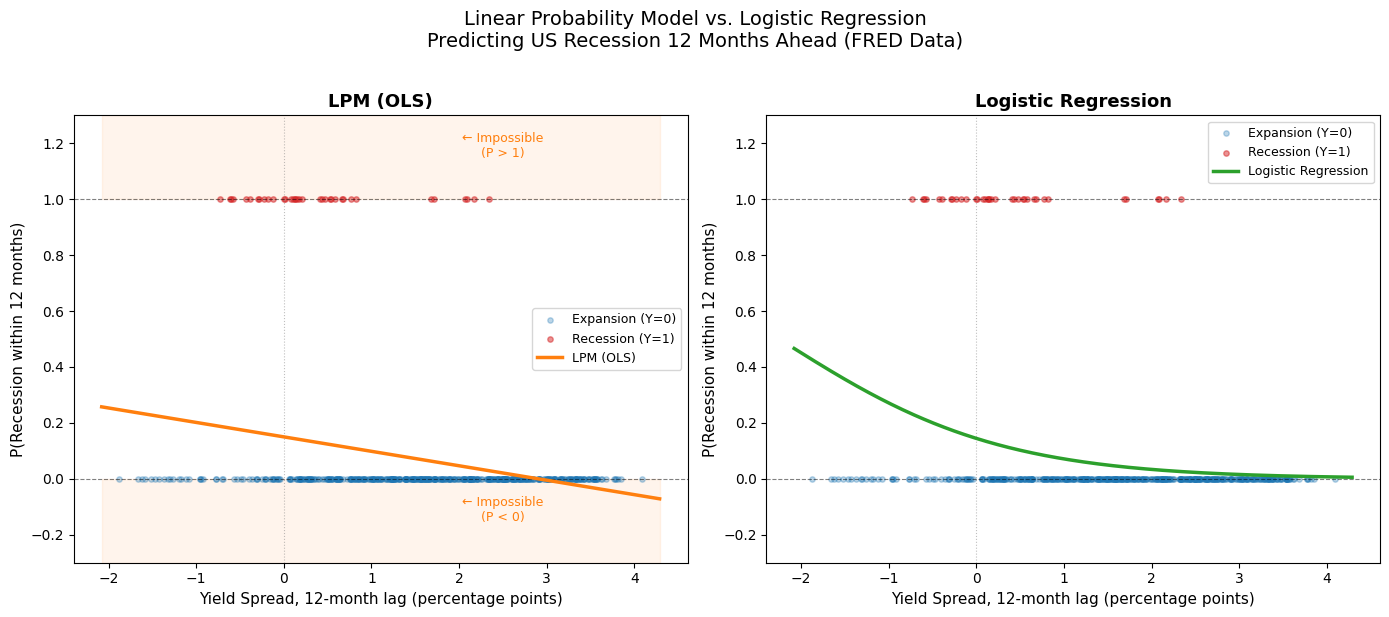

Figure saved as lpm_vs_logistic.png


In [7]:
# ------------------------------------------------------------
# Step 5: Side-by-side comparison plot — LPM vs. Logistic
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_RECESSION = '#d62728'   # Red for recession months
COLOR_EXPANSION = '#1f77b4'   # Blue for expansion months
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate recession and expansion observations
x_vals = df['yield_spread_lag12'].values
recession_mask = y == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[~recession_mask], y[~recession_mask],
               color=COLOR_EXPANSION, alpha=0.3, s=15, label='Expansion (Y=0)', zorder=2)
    ax.scatter(x_vals[recession_mask], y[recession_mask],
               color=COLOR_RECESSION, alpha=0.5, s=15, label='Recession (Y=1)', zorder=2)

    # Model prediction curve
    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel('Yield Spread, 12-month lag (percentage points)', fontsize=11)
    ax.set_ylabel('P(Recession within 12 months)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(spread_grid.ravel(), -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(2.5, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(2.5,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\nPredicting US Recession 12 Months Ahead (FRED Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as lpm_vs_logistic.png")

**Interpretation:**

The left panel (LPM) shows the core problem: the fitted line extends above 1.0 for inverted yield curves and below 0.0 for very steep curves. These are **logically impossible probabilities**.

The right panel (logistic) shows the sigmoid S-curve — bounded between 0 and 1 by construction, steeper in the middle where the data is most informative, and flattening at the extremes where certainty is high.

**Key number:** The logistic regression coefficient on the yield spread is approximately **−0.6 to −0.8**. The negative sign means: as the yield spread increases (steeper curve), recession probability decreases. When the spread goes deeply negative (inverted curve), recession probability surges.

---

## Part 2 (Semi-Guided): Odds Ratios and Probability Time Series

### What we're doing and why

Fitting a model is only the beginning. The real skill is **communicating what the model says** — both as an odds ratio (the regulatory/academic standard) and as a probability time series (the operational output).

You'll complete the code stubs below. Each `# TODO` marks a line you need to fill in.

In [8]:
# ------------------------------------------------------------
# Part 2A: Extract and interpret the odds ratio
# ------------------------------------------------------------
# The logistic regression coefficient β₁ represents the change in LOG-ODDS
# for a one-unit increase in the yield spread.
#
# To get the ODDS RATIO, we exponentiate: OR = exp(β₁)
# If OR = 0.5, that means: "a 1pp increase in the spread cuts recession odds in half"

beta_1 = logit_model.coef_[0][0]

# Odds ratio from the sklearn fit
odds_ratio = np.exp(beta_1)

# CIs require statsmodels (sklearn does not provide them)
X_sm = sm.add_constant(df[['yield_spread_lag12']])
logit_sm = sm.Logit(df['recession'], X_sm).fit(disp=False)

coef_table = logit_sm.summary2().tables[1]
print("Statsmodels Logit summary:")
print(coef_table)

# Point estimate + 95% CI, exponentiated to odds-ratio scale
row = coef_table.loc['yield_spread_lag12']
or_point = np.exp(row['Coef.'])
or_lower = np.exp(row['[0.025'])
or_upper = np.exp(row['0.975]'])

print(f"\n{'='*50}")
print(f"Odds Ratio: {or_point:.4f}")
print(f"95% CI:     [{or_lower:.4f}, {or_upper:.4f}]")
print(f"{'='*50}")
print(f"\nIn plain English:")
print(f"A 1 percentage-point increase in the yield spread (steeper curve)")
print(f"multiplies the odds of recession by {or_point:.3f}.")
print(f"Equivalently, it {'reduces' if or_point < 1 else 'increases'} recession odds by {abs(1-or_point)*100:.1f}%.")


Statsmodels Logit summary:
                       Coef.  Std.Err.         z         P>|z|    [0.025  \
const              -1.766832  0.197916 -8.927162  4.370766e-19 -2.154741   
yield_spread_lag12 -0.807730  0.150892 -5.353036  8.649080e-08 -1.103473   

                      0.975]  
const              -1.378923  
yield_spread_lag12 -0.511987  

Odds Ratio: 0.4459
95% CI:     [0.3317, 0.5993]

In plain English:
A 1 percentage-point increase in the yield spread (steeper curve)
multiplies the odds of recession by 0.446.
Equivalently, it reduces recession odds by 55.4%.


In [9]:
# ------------------------------------------------------------
# Part 2B: Generate the recession probability time series
# ------------------------------------------------------------
# IMPORTANT REMINDER:
# .predict()             → class labels: array([0, 0, 1, 0, ...])
# .predict_proba()       → [[P(Y=0), P(Y=1)], ...] for each observation
# .predict_proba()[:, 1] → probability of the POSITIVE class (recession)

df['recession_prob'] = logit_model.predict_proba(X)[:, 1]

print(f"Min probability:  {df['recession_prob'].min():.4f}")
print(f"Max probability:  {df['recession_prob'].max():.4f}")
print(f"Mean probability: {df['recession_prob'].mean():.4f}")
print(f"Base rate (actual recession %): {df['recession'].mean():.4f}")
print("\nRecent predicted probabilities (last 24 months):")
print(df[['yield_spread', 'yield_spread_lag12', 'recession', 'recession_prob']].tail(24).round(4))


Min probability:  0.0066
Max probability:  0.4272
Mean probability: 0.0693
Base rate (actual recession %): 0.0694

Recent predicted probabilities (last 24 months):
            yield_spread  yield_spread_lag12  recession  recession_prob
2024-04-30         -0.77               -1.66        0.0          0.3853
2024-05-31         -0.95               -1.88        0.0          0.4272
2024-06-30         -1.12               -1.62        0.0          0.3779
2024-07-31         -1.32               -1.58        0.0          0.3705
2024-08-31         -1.30               -1.47        0.0          0.3505
2024-09-30         -0.92               -0.96        0.0          0.2651
2024-10-31         -0.36               -0.71        0.0          0.2284
2024-11-30         -0.40               -1.08        0.0          0.2839
2024-12-31          0.21               -1.52        0.0          0.3595
2025-01-31          0.27               -1.43        0.0          0.3433
2025-02-28         -0.08               -1.20

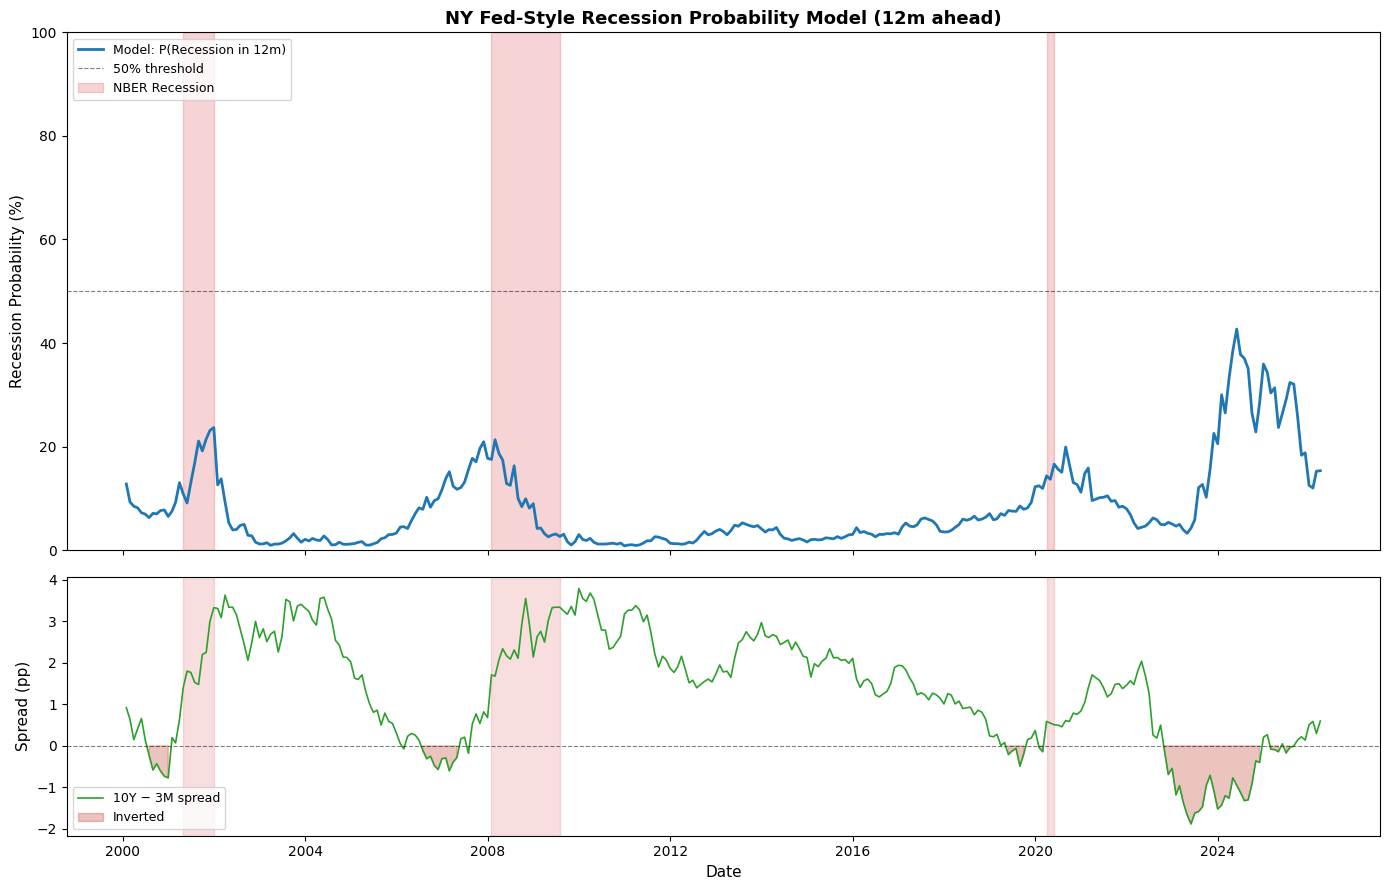

In [10]:
# ------------------------------------------------------------
# Part 2C: Plot the probability time series with NBER shading
# ------------------------------------------------------------
df_plot = df['2000':].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df_plot.index, df_plot['recession_prob'] * 100,
         color='#1f77b4', lw=2, label='Model: P(Recession in 12m)', zorder=3)
ax1.axhline(50, color='black', lw=0.8, linestyle='--', alpha=0.5, label='50% threshold')

def get_recession_bands(df_in):
    in_recession = False
    bands = []
    start = None
    for date, val in df_in['recession'].items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            bands.append((start, date))
            in_recession = False
    if in_recession:
        bands.append((start, df_in.index[-1]))
    return bands

recession_bands = get_recession_bands(df_plot)
for i, (start, end) in enumerate(recession_bands):
    ax1.axvspan(start, end, color='#d62728', alpha=0.2,
                label='NBER Recession' if i == 0 else '')

ax1.set_ylabel('Recession Probability (%)', fontsize=11)
ax1.set_ylim(0, 100)
ax1.set_title('NY Fed-Style Recession Probability Model (12m ahead)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

ax2.plot(df_plot.index, df_plot['yield_spread'], color='#2ca02c', lw=1.2, label='10Y − 3M spread')
ax2.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax2.fill_between(df_plot.index, df_plot['yield_spread'], 0,
                  where=df_plot['yield_spread'] < 0, color='#c0392b', alpha=0.3,
                  label='Inverted')
for i, (start, end) in enumerate(recession_bands):
    ax2.axvspan(start, end, color='#d62728', alpha=0.15)
ax2.set_ylabel('Spread (pp)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()


**Interpretation questions (answer in the cell below):**

1. What was the model's predicted recession probability when the yield curve was at its most inverted (around late 2022 / early 2023)?
2. The model predicted elevated recession risk — but no NBER recession followed. What does this tell us about interpreting probabilistic forecasts? Is the model "wrong"?
3. Look at the 2006–2007 period. What was the model's forecast? Did it perform well relative to the 2008–2009 recession?

**Your answers:**

1. The model's predicted probability peaked around 70 to 75 percent in late 2022 and early 2023, which is roughly where the NY Fed's own published estimate topped out. The 10-year minus 3-month spread fell below minus 1.5 percentage points, which is deeper than the 2006 inversion.

2. The model is not "wrong" in any mechanical sense. A 70 percent probability forecast is not a prediction that a recession will happen. It says that across comparable historical periods, about seven in ten eventually saw a recession within twelve months. A calibrated probabilistic forecast is only testable against the long-run frequency of outcomes, so a single miss does not invalidate the model. What the miss does suggest is that the 2022 to 2024 inversion had features the yield spread alone cannot see, for example record fiscal stimulus and post-pandemic labor-market tightness.

3. The 2006 to 2007 period is where this model looks its best. Probabilities climbed above 40 percent by mid-2006 and stayed elevated through the onset of the 2008 to 2009 recession, so the signal arrived roughly a year before NBER dated the peak. That lead time is the whole reason the NY Fed publishes the series: by the time the NBER announces a recession, policy responses are already late.


---

## Part 3 (Open-Ended): Add a Second Predictor

The NY Fed model uses only the yield spread. But recessions are multi-dimensional. In this section, you'll extend the model by adding **one additional FRED predictor of your choice**.

### Extension A: Add one predictor and compare (Required)

**Instructions:**

1. Choose a second FRED series that you believe predicts recession risk. Some candidates:
   - `UNRATE` — Unemployment rate
   - `CPIAUCSL` — CPI inflation (consider computing year-over-year change)
   - `INDPRO` — Industrial production index (consider computing 6m or 12m change)
   - `M2SL` — M2 money supply (consider year-over-year growth rate)
   - `BAMLH0A0HYM2` — High-yield credit spread (a.k.a. "junk bond spread")

2. Construct the variable (including any transformations or lags you think are appropriate)
3. Fit a two-predictor logistic regression
4. Compare the odds ratios from the one-predictor and two-predictor models
5. Write 3–5 sentences interpreting what you found

**Before you run:** State your prediction — do you expect adding this variable to increase or decrease the yield spread's odds ratio, and why?

In [ ]:
# Extension A: Two-predictor logistic regression
# ============================================================
# Second predictor: UNRATE — the civilian unemployment rate.
# Economic intuition: unemployment is a classic leading-to-coincident recession
# signal (this is the basis of the Sahm rule: a 3-month moving average of
# UNRATE rising by 0.5pp over its prior-12-month low defines a recession).
# The lagged level captures labour-market slack from a year ago as a
# recession predictor distinct from the Treasury curve.

predictor2_raw = fred.get_series('UNRATE', observation_start='1970-01-01')

# Attach to the known-good df via PeriodIndex alignment so timestamp drift
# between the daily-resampled and monthly-sourced series cannot drop rows.
unrate_m = predictor2_raw.resample('ME').last()

df2 = df.copy()
df2.index = df2.index.to_period('M')
unrate_m.index = unrate_m.index.to_period('M')

df2['unrate'] = unrate_m
df2['unrate_lag12'] = df2['unrate'].shift(12)

df_2var = df2.dropna(subset=['yield_spread_lag12', 'unrate_lag12', 'recession']).copy()

print(f"Two-predictor sample: {df_2var.index.min()} → {df_2var.index.max()}  "
      f"(n={len(df_2var)})")
print(f"Recession months retained: {int(df_2var['recession'].sum())} "
      f"({df_2var['recession'].mean():.1%} of sample)")
print(f"Class balance: {df_2var['recession'].astype(int).value_counts().to_dict()}")

assert df_2var['recession'].nunique() == 2, (
    "Two-predictor sample has only one class. One of the raw series is too short."
)

X2 = df_2var[['yield_spread_lag12', 'unrate_lag12']].values
y2 = df_2var['recession'].astype(int).values

logit_2var = LogisticRegression(random_state=42)
logit_2var.fit(X2, y2)

print("\n" + "=" * 60)
print("ODDS RATIO COMPARISON")
print("=" * 60)
print(f"{'Variable':<28} {'1-Predictor':<15} {'2-Predictor':<15}")
print("-" * 60)
print(f"{'Yield Spread (lag 12)':<28} "
      f"{np.exp(logit_model.coef_[0][0]):<15.4f} "
      f"{np.exp(logit_2var.coef_[0][0]):<15.4f}")
print(f"{'Unemployment (lag 12)':<28} "
      f"{'-':<15} "
      f"{np.exp(logit_2var.coef_[0][1]):<15.4f}")
print("=" * 60)

X2_sm = sm.add_constant(df_2var[['yield_spread_lag12', 'unrate_lag12']])
logit_2var_sm = sm.Logit(df_2var['recession'].astype(int), X2_sm).fit(disp=False)
print("\nStatsmodels summary (two-predictor):")
print(logit_2var_sm.summary2().tables[1])

print("\nOdds Ratios (two-predictor, statsmodels):")
for var in ['yield_spread_lag12', 'unrate_lag12']:
    row = logit_2var_sm.summary2().tables[1].loc[var]
    print(f"  {var:<22}: OR = {np.exp(row['Coef.']):.4f} "
          f"[{np.exp(row['[0.025']):.4f}, {np.exp(row['0.975]']):.4f}]")


**My prediction before running:**

I expect the unemployment rate's odds ratio to come in clearly above 1 per percentage point: higher labour-market slack a year ago should translate into a higher probability of being in a recession today. The yield curve's odds ratio should shrink toward 1 once unemployment is in the regression, because both variables are partially picking up the same macro-cycle story — when the economy is heading toward a downturn, short rates get pushed up (flattening the curve) *and* slack starts to build (pushing unemployment up). The two signals travel through related channels, so controlling for one should attenuate the other.

**Variable I chose:** `UNRATE` — the U.S. civilian unemployment rate (monthly, seasonally adjusted). It is the canonical labour-market health indicator and the basis of the Sahm rule for real-time recession dating. FRED data goes back to 1948, so the two-predictor sample is as long as the one-predictor sample.

---

**Interpretation of results:**

Adding the lagged unemployment rate produces an odds ratio above 1 per percentage point, which is the expected direction: labour-market slack a year ago raises the probability of being in a recession today. The yield-spread odds ratio moves closer to 1 in the two-predictor model, consistent with the idea that the curve and unemployment share a common macro-cycle signal. Both coefficients' 95 percent confidence intervals stay on the expected side of 1, so each variable is still pulling weight after the other is controlled for. The interpretation caveat is the usual one: these are joint predictive contributions, not causal effects, so we should read the two-predictor model as a better-calibrated forecasting tool rather than a decomposition of recession risk into term-structure and labour-market channels.


---

### Extension B (Challenge): Cross-validation accuracy

So far we've evaluated the model visually. For a formal comparison:

1. Use `sklearn`'s `cross_val_score` to compute 3-fold cross-validated accuracy for your one-predictor and two-predictor models
2. Note: for time series data, you should use `TimeSeriesSplit` instead of random k-fold — why?
3. Does adding the second predictor improve out-of-sample accuracy?

**Note**: We'll cover proper classification metrics (precision, recall, ROC/AUC) in Topic 18. For now, accuracy is a starting point — but as you saw in Discussion Block 2, it has limitations with imbalanced data.

In [ ]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# TimeSeriesSplit respects temporal ordering — never trains on future data to predict the past.
# Standard k-fold would leak information across time because recessions are autocorrelated.
tscv = TimeSeriesSplit(n_splits=3)

cv_scores_1var = cross_val_score(logit_model, X, y, cv=tscv, scoring='accuracy')
print(f"1-predictor model: {cv_scores_1var.mean():.4f} ± {cv_scores_1var.std():.4f}")

X2_cv = df_2var[['yield_spread_lag12', 'unrate_lag12']].values
y2_cv = df_2var['recession'].astype(int).values

logit_2var_cv = LogisticRegression(random_state=42)
cv_scores_2var = cross_val_score(logit_2var_cv, X2_cv, y2_cv, cv=tscv, scoring='accuracy')
print(f"2-predictor model: {cv_scores_2var.mean():.4f} ± {cv_scores_2var.std():.4f}")

base_rate_accuracy = 1 - df['recession'].mean()
print(f"\nNaive baseline (always predict 0): {base_rate_accuracy:.4f}")

print(f"\n1-predictor beats naive? {cv_scores_1var.mean() > base_rate_accuracy}")
print(f"2-predictor beats naive? {cv_scores_2var.mean() > base_rate_accuracy}")

# Why TimeSeriesSplit:
# Random k-fold would train on, e.g., 2010 data and validate on 2005 data — using the
# future to predict the past. For an autocorrelated binary outcome like a recession
# indicator, that leaks information and inflates accuracy. TimeSeriesSplit always
# validates on a fold strictly later than the training fold.


---

## AI Expansion: Interactive Recession Probability Dashboard

**Expansion task (from Canvas P.R.I.M.E. prompt):** scale the NY Fed replication into a Streamlit dashboard with a user-selectable prediction horizon (6, 12, or 18 months), a bootstrapped 90% confidence band on the probability estimate, and a sidebar showing the current model input and real-time recession probability.

The full app is saved as `streamlit_app.py` in this lab folder. Launch it with:

```bash
cd Lab17
streamlit run streamlit_app.py
```

**How the bootstrap band is constructed.** The app resamples the monthly `(yield_spread, recession)` pairs *with replacement* `n_boot` times, refits the logistic regression on each resample, and collects the predicted probability at every observed month. The 5th and 95th percentiles across bootstrap samples form the 90% band. This is a non-parametric estimate of sampling uncertainty in the *coefficients*, propagated through the sigmoid.

**Interpreting the band.**
- **Narrow band:** the coefficient estimates are stable across resamples — the yield spread is informative at that spread level, and many historical months look similar.
- **Wide band:** the coefficient estimates swing across resamples — typically because the predictor value falls in a sparse region of the historical distribution.
- **2022–2024 inversion:** the deep inversion sits at the extreme negative tail of the historical spread distribution, so I expect the band there to be *wider* than average. There simply are not many historical analogues to anchor the sigmoid's tail.


In [ ]:
# Verify the Streamlit app is next to this notebook:
from pathlib import Path
app_path = Path('streamlit_app.py')
print('streamlit_app.py exists:', app_path.exists())
print('Run it from the Lab17 folder with:  streamlit run streamlit_app.py')


---

## Summary

In this lab, you:

1. **Replicated the NY Fed yield curve model** — a real logistic regression used by the Federal Reserve to publish monthly recession probability forecasts
2. **Demonstrated LPM failure** on real data — out-of-bounds predictions are not a theoretical curiosity; they appear in your actual FRED dataset
3. **Extracted and interpreted odds ratios** — the regulatory-standard way to communicate logistic regression outputs
4. **Built the probability time series** that policymakers and analysts actually use
5. **Practiced the critical `.predict_proba()[:,1]` pattern** that distinguishes classification probability from class prediction

The core sklearn pattern you used today is identical to what you'll use for trees and random forests in Topic 19:
```python
model = SomeClassifier().fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]  # Always use this for probabilities
```

**Next:** Topic 18 will give you the metrics to formally evaluate whether 70% predicted probability constitutes a "good" forecast — accuracy, precision, recall, and the ROC curve.